<a href="https://colab.research.google.com/github/Akakiikent/Sumwork/blob/main/semantic_search_comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -U sentence-transformers scikit-learn pandas matplotlib

import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer, util
from sklearn.manifold import TSNE

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [3]:
with open("code_corpus.json", encoding="utf-8") as f:
    corpus = json.load(f)

with open("eval_questions.json", encoding="utf-8") as f:
    eval_questions = json.load(f)

with open("categories.json", encoding="utf-8") as f:
    categories_raw = json.load(f)["categories"]

category_color = {c["key"]: c["color"] for c in categories_raw}
category_label = {c["key"]: c["label"] for c in categories_raw}

print(f"Фрагментов кода в корпусе: {len(corpus)}")
print(f"Тестовых вопросов: {len(eval_questions)}")

corpus_df = pd.DataFrame(corpus)
corpus_df["category"].value_counts()

Фрагментов кода в корпусе: 200
Тестовых вопросов: 25


category
auth          40
database      40
http          40
validation    40
utils         40
Name: count, dtype: int64

In [4]:

corpus_texts = [f"{c['function_name']}: {c['description']}" for c in corpus]
corpus_ids = [c["id"] for c in corpus]
corpus_categories = [c["category"] for c in corpus]

queries = [q["query"] for q in eval_questions]
correct_ids = [q["correct_chunk_id"] for q in eval_questions]
query_languages = [q["language"] for q in eval_questions]

print("Пример текста для эмбеддинга:", corpus_texts[0])
print("Пример запроса:", queries[0], "-> правильный ответ:", correct_ids[0])

Пример текста для эмбеддинга: verify_jwt_token: Проверяет JWT-токен и возвращает payload или причину невалидности.
Пример запроса: как проверить, истёк ли токен? -> правильный ответ: func_001


In [5]:
MODEL_CONFIGS = {
    "MiniLM-multilingual": {
        "name": "paraphrase-multilingual-MiniLM-L12-v2",
        "query_prefix": "",
        "passage_prefix": "",
    },
    "MPNet-multilingual": {
        "name": "paraphrase-multilingual-mpnet-base-v2",
        "query_prefix": "",
        "passage_prefix": "",
    },
    "E5-multilingual (бонус)": {
        "name": "intfloat/multilingual-e5-base",
        "query_prefix": "query: ",
        "passage_prefix": "passage: ",
    },
}

In [6]:
def encode_corpus_and_queries(model, cfg):
    passage_texts = [cfg["passage_prefix"] + t for t in corpus_texts]
    query_texts = [cfg["query_prefix"] + q for q in queries]

    corpus_emb = model.encode(passage_texts, normalize_embeddings=True, show_progress_bar=False)
    query_emb = model.encode(query_texts, normalize_embeddings=True, show_progress_bar=False)
    return corpus_emb, query_emb


def top_k_search(query_emb, corpus_emb, k=3):
    sims = util.cos_sim(query_emb, corpus_emb).numpy()  # (n_queries, n_corpus)
    top_idx = np.argsort(-sims, axis=1)[:, :k]
    return top_idx, sims
def precision_at_k(top_idx):
    hits = 0
    per_question_hit = []
    for i, idx_row in enumerate(top_idx):
        retrieved_ids = [corpus_ids[j] for j in idx_row]
        hit = correct_ids[i] in retrieved_ids
        per_question_hit.append(hit)
        hits += int(hit)
    return hits / len(top_idx), per_question_hit

In [7]:
results = {}

for model_label, cfg in MODEL_CONFIGS.items():
    print(f"Загружаю модель: {cfg['name']} ...")
    t0 = time.time()
    model = SentenceTransformer(cfg["name"])
    load_time = time.time() - t0

    t0 = time.time()
    corpus_emb, query_emb = encode_corpus_and_queries(model, cfg)
    encode_time = time.time() - t0

    top_idx, sims = top_k_search(query_emb, corpus_emb, k=3)
    precision, per_question_hit = precision_at_k(top_idx)

    results[model_label] = {
        "model_name": cfg["name"],
        "corpus_emb": corpus_emb,
        "query_emb": query_emb,
        "top_idx": top_idx,
        "precision_at_3": precision,
        "per_question_hit": per_question_hit,
        "load_time_sec": load_time,
        "encode_time_sec": encode_time,
        "dim": corpus_emb.shape[1],
    }
    print(f"  Precision@3 = {precision:.3f}, размерность = {corpus_emb.shape[1]}, кодирование = {encode_time:.1f}с\n")

Загружаю модель: paraphrase-multilingual-MiniLM-L12-v2 ...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

  Precision@3 = 1.000, размерность = 768, кодирование = 27.8с



In [8]:
comparison_df = pd.DataFrame([
    {
        "Модель": label,
        "HF-имя": r["model_name"],
        "Precision@3": round(r["precision_at_3"], 3),
        "Размерность вектора": r["dim"],
        "Время кодирования, с": round(r["encode_time_sec"], 1),
    }
    for label, r in results.items()
]).sort_values("Precision@3", ascending=False).reset_index(drop=True)

comparison_df.to_csv("comparison_table.csv", index=False)
comparison_df

,Модель,HF-имя,Precision@3,Размерность вектора,"Время кодирования, с"
0,E5-multilingual (бонус),intfloat/multilingual-e5-base,1.00,768,27.8
1,MPNet-multilingual,paraphrase-multilingual-mpnet-base-v2,0.92,768,25.4
2,MiniLM-multilingual,paraphrase-multilingual-MiniLM-L12-v2,0.84,384,6.8


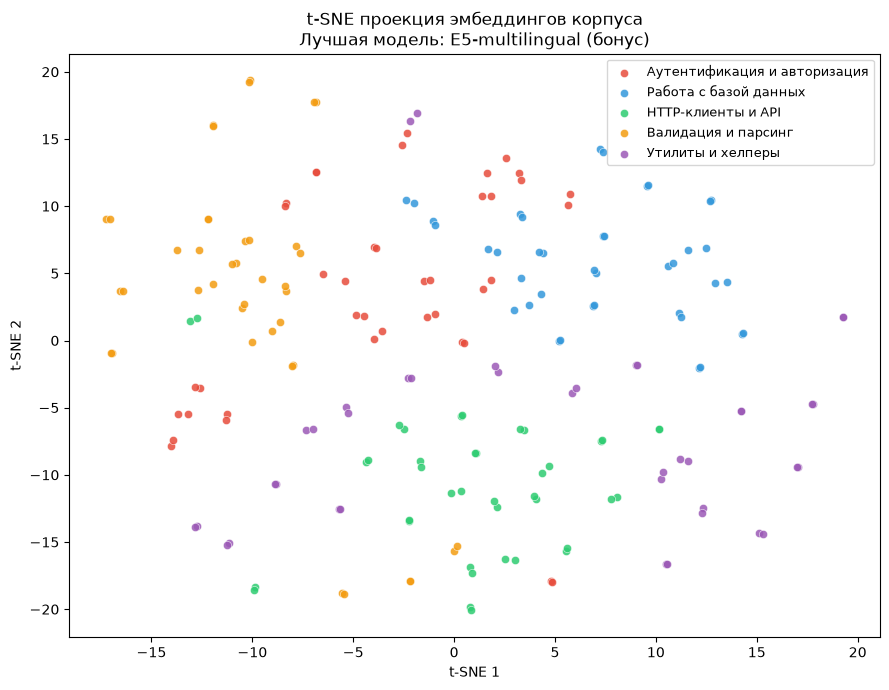

In [9]:
best_model_label = comparison_df.iloc[0]["Модель"]
best_emb = results[best_model_label]["corpus_emb"]

coords = TSNE(
    n_components=2,
    random_state=RANDOM_STATE,
    perplexity=30,
    init="pca",
).fit_transform(best_emb)

plt.figure(figsize=(9, 7))
for cat_key in category_color:
    mask = [c == cat_key for c in corpus_categories]
    plt.scatter(
        coords[mask, 0], coords[mask, 1],
        c=category_color[cat_key],
        label=category_label[cat_key],
        s=35, alpha=0.85, edgecolors="white", linewidths=0.4,
    )

plt.title(f"t-SNE проекция эмбеддингов корпуса\nЛучшая модель: {best_model_label}")
plt.legend(loc="best", fontsize=9)
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.tight_layout()
plt.savefig("tsne_plot.png", dpi=150)
plt.show()